In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [2]:
df = pd.read_csv('../data/q1_heart_disease.csv')
df.head()

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


In [3]:
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

Shape: (800, 12)

Data Types:
 age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

Missing Values:
 age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


This Dataset contains patient health related attributes along with a binary target variable indicating the presence of heart disease. missing values are observed in some numerical columns such as resting blood pressure and Cholesterol.

In [4]:
# fill missing values before encoding/scaling

# numerical columns
num_cols = df.select_dtypes(include=['int64','float64']).columns

# fill with median
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# verify
print(df.isnull().sum())

age                0
sex                0
chest_pain_type    0
resting_bp         0
cholesterol        0
fasting_bs         0
resting_ecg        0
max_hr             0
exercise_angina    0
oldpeak            0
st_slope           0
heart_disease      0
dtype: int64


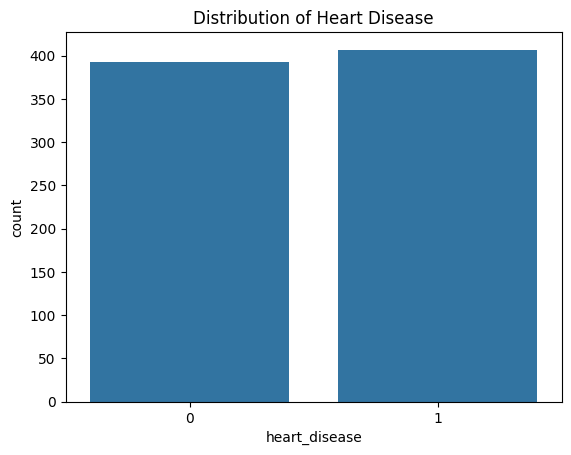

In [5]:
sns.countplot(x='heart_disease', data=df)
plt.title("Distribution of Heart Disease")
plt.show()

The Target variable appears reasonably balanced.which is beneficial for training classification models without bias toward one class

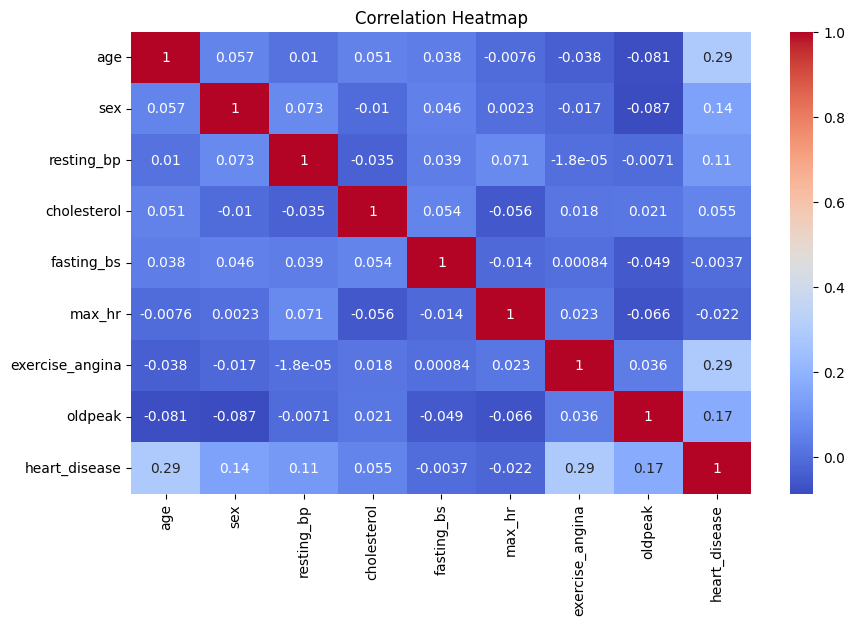

In [6]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Some features such as like max_hr, oldpeak etc.. show correlation with the target variable, which may help the model in prediction

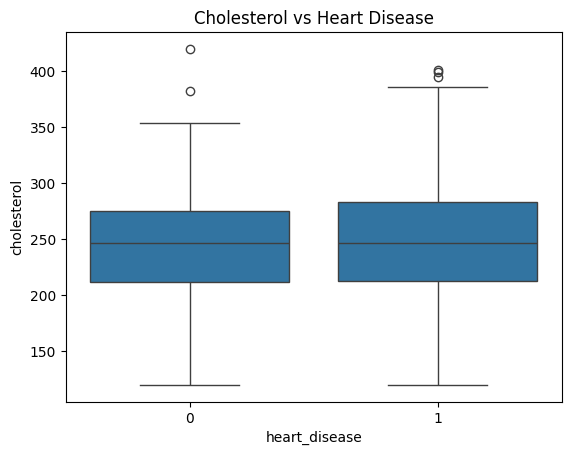

In [7]:
sns.boxplot(x='heart_disease', y='cholesterol', data=df)
plt.title("Cholesterol vs Heart Disease")
plt.show()

Patients with Heart disease (1) have slightly higher median Cholesterol than those without (0). however There is a lot of overlap between these two groups, so cholesterol alone is not a strong predictor.Outliers are present in both the cases.

In [8]:
df_processed = df.copy()

# One-hot encoding for categorical columns
categorical_cols = ['sex', 'chest_pain_type', 'resting_ecg', 'exercise_angina', 'st_slope']
df_processed = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)

# Split features and target
X = df_processed.drop('heart_disease', axis=1)
y = df_processed['heart_disease']

categorical variables were converted into Numerical form using one-hot encoding.this allows ML models to interpret categorical data effectively and better.

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

The Dataset is split using stratification to preserve class distribution. this scaling ensures that all features contribute equally to the Model.

In [10]:
#Train Models
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)

dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [11]:
#Evaluation function
def evaluate(model, name):
    y_pred = model.predict(X_test)

    print(f"\n{name}")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))

In [12]:
evaluate(dt, "Decision Tree")
evaluate(rf, "Random Forest")
evaluate(gb, "Gradient Boosting")


Decision Tree
[[59 20]
 [23 58]]
              precision    recall  f1-score   support

           0       0.72      0.75      0.73        79
           1       0.74      0.72      0.73        81

    accuracy                           0.73       160
   macro avg       0.73      0.73      0.73       160
weighted avg       0.73      0.73      0.73       160


Random Forest
[[57 22]
 [17 64]]
              precision    recall  f1-score   support

           0       0.77      0.72      0.75        79
           1       0.74      0.79      0.77        81

    accuracy                           0.76       160
   macro avg       0.76      0.76      0.76       160
weighted avg       0.76      0.76      0.76       160


Gradient Boosting
[[61 18]
 [19 62]]
              precision    recall  f1-score   support

           0       0.76      0.77      0.77        79
           1       0.78      0.77      0.77        81

    accuracy                           0.77       160
   macro avg       0.7

among the models, the best performing model is selected based on a balance between Precision, Recall and F1-score rather than Accuracy alone

In [13]:
#hyper parameter tuning
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, None]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid,
                    cv=3,
                    scoring='f1')

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'max_depth': None, 'n_estimators': 100}


In [14]:
#evaluate Tuned model
best_model = grid.best_estimator_
evaluate(best_model, "Tuned Random Forest")


Tuned Random Forest
[[57 22]
 [17 64]]
              precision    recall  f1-score   support

           0       0.77      0.72      0.75        79
           1       0.74      0.79      0.77        81

    accuracy                           0.76       160
   macro avg       0.76      0.76      0.76       160
weighted avg       0.76      0.76      0.76       160



Hyperparameter Tuning improved model performance by optimizing key parameters,The tuned model provides better generalization compared to the Baseline Model